<a href="https://colab.research.google.com/github/mjjaiavinash/avinash-codebooster-2026/blob/main/Day_3_Miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
API_KEY = '576cc3a978403901abae8e5c256f1e20'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']
print("API Configured:",len(CITIES))
print(CITIES)

API Configured: 8
['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [17]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')

In [19]:
Chennai_city = fetch_weather(CITIES[3],API_KEY)
print("Fetching the API KEY !!!!!!")
print("")
if Chennai_city:
  print(Chennai_city)
else:
  print('Error fetching weather data')

Fetching the API KEY !!!!!!

{'city': 'Chennai', 'temperature': 35.9, 'description': 'few clouds', 'humidity': 53, 'wind_speed': 5.14, 'pressure': 1005, 'condition': 'Few Clouds', 'visibility': 6}


In [37]:
# FULL WORKING CODE #

import requests
import pandas as pd

weather_records = []

def fetch_weather(city, api_key):

    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=10
        )

        if response.status_code == 200:

            data = response.json()

            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'description': data['weather'][0]['description'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }

        else:

            print(
                f"Error {response.status_code} for {city}"
            )

            return None

    except requests.exceptions.ConnectionError:

        print("Connection Error")
        return None

    except requests.exceptions.Timeout:

        print("Request Timeout")
        return None


# Fetch all cities weather

for city in CITIES:

    result = fetch_weather(city, API_KEY)

    if result:

        weather_records.append(result)


# Convert into dataframe

weather_df = pd.DataFrame(weather_records)

print("Weather dataframe created\n")

print(weather_df.to_string(index=False))

print("\nShape:", weather_df.shape)

print()
print("="*150)

print("\nMissing Values:")
print(weather_df.isnull().sum())

print()
print("="*140)

print("\nData Types:")
print(weather_df.dtypes)

Weather dataframe created

     city  temperature      description  humidity  wind_speed  pressure        condition  visibility
   Mumbai         33.0             haze        58        4.63      1009             Haze           7
    Delhi         44.0        clear sky        10        5.14       999        Clear Sky           7
Bangalore         29.7 scattered clouds        55        6.71      1010 Scattered Clouds           8
  Chennai         35.5       few clouds        55        6.17      1005       Few Clouds           6
Hyderabad         31.2    broken clouds        48        7.20      1010    Broken Clouds           6
  Kolkata         32.0             haze        66        3.60      1001             Haze           5
     Pune         36.3  overcast clouds        26        3.76      1008  Overcast Clouds          10
   Jaipur         42.6             haze        14        5.66      1001             Haze           5

Shape: (8, 8)


Missing Values:
city           0
temperature   

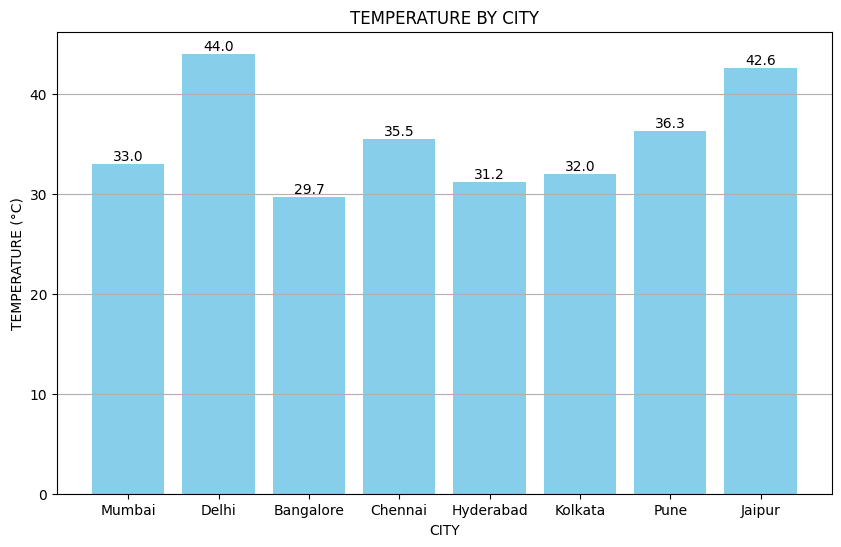

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

bars = plt.bar(
    weather_df['city'],
    weather_df['temperature'],
    color='skyblue'
)

plt.title("TEMPERATURE BY CITY")
plt.xlabel("CITY")
plt.ylabel("TEMPERATURE (°C)")

# Add values on bars
for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        round(value,1),
        ha='center'
    )

plt.grid(axis='y')

plt.show()

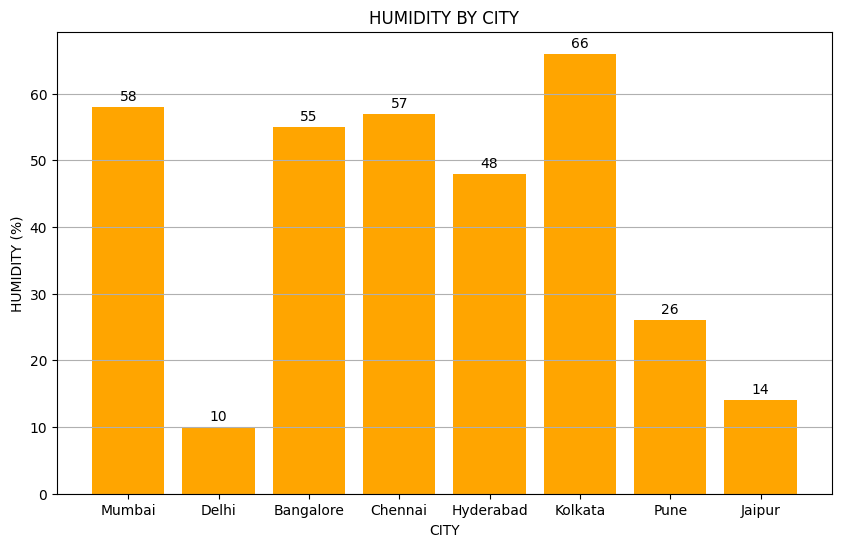

In [35]:
fig, ax = plt.subplots(figsize=(10,6))

bars = plt.bar(
    weather_df['city'],
    weather_df['humidity'],
    color='orange'
)

plt.title("HUMIDITY BY CITY")
plt.xlabel("CITY")
plt.ylabel("HUMIDITY (%)")

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        value,
        ha='center'
    )

plt.grid(axis='y')

plt.show()

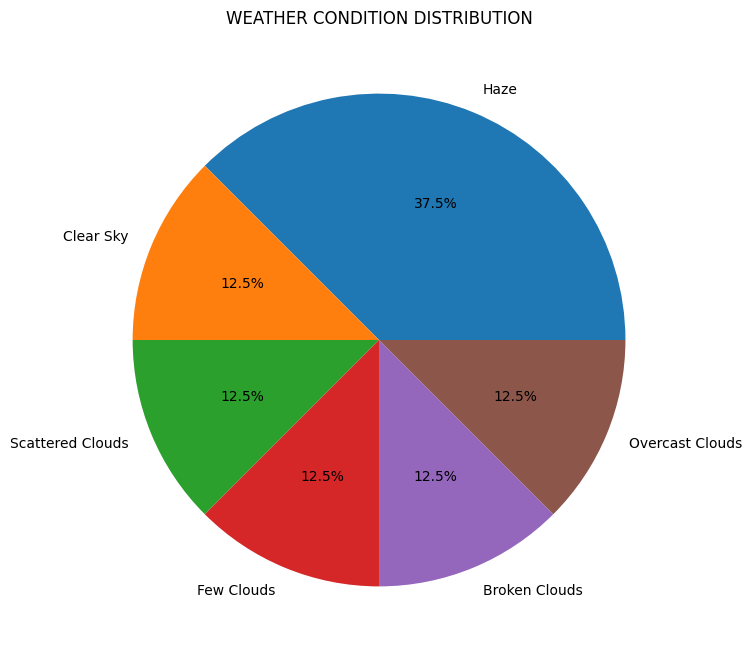

In [38]:
condition_count = weather_df['condition'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    condition_count.values,
    labels=condition_count.index,
    autopct='%1.1f%%'
)

plt.title("WEATHER CONDITION DISTRIBUTION")

plt.show()

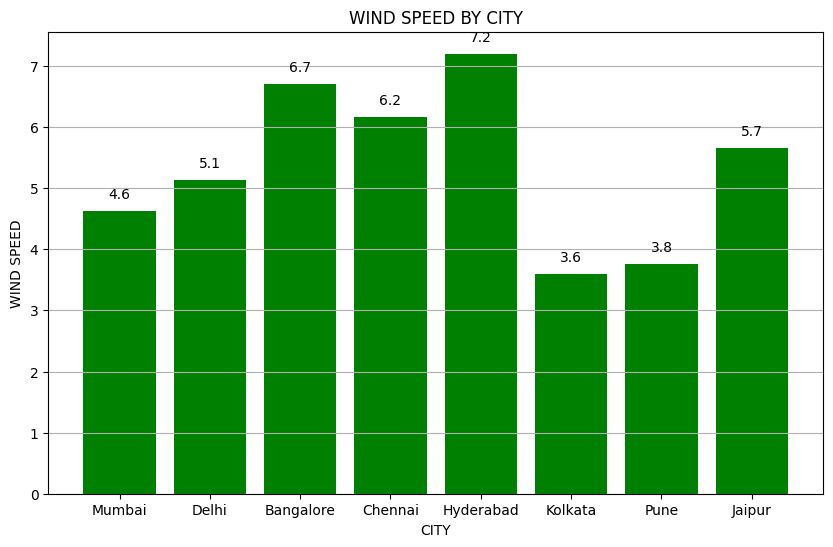

In [39]:
fig, ax = plt.subplots(figsize=(10,6))

bars = plt.bar(
    weather_df['city'],
    weather_df['wind_speed'],
    color='green'
)

plt.title("WIND SPEED BY CITY")
plt.xlabel("CITY")
plt.ylabel("WIND SPEED")

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        round(value,1),
        ha='center'
    )

plt.grid(axis='y')

plt.show()

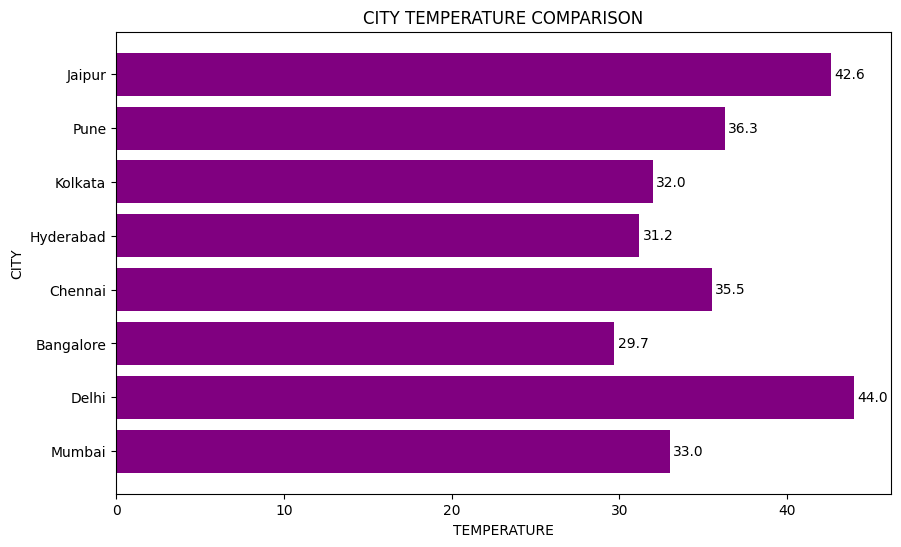

In [40]:
fig, ax = plt.subplots(figsize=(10,6))

bars = plt.barh(
    weather_df['city'],
    weather_df['temperature'],
    color='purple'
)

plt.title("CITY TEMPERATURE COMPARISON")
plt.xlabel("TEMPERATURE")
plt.ylabel("CITY")

for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.2,
        bar.get_y() + bar.get_height()/2,
        round(value,1),
        va='center'
    )

plt.show()

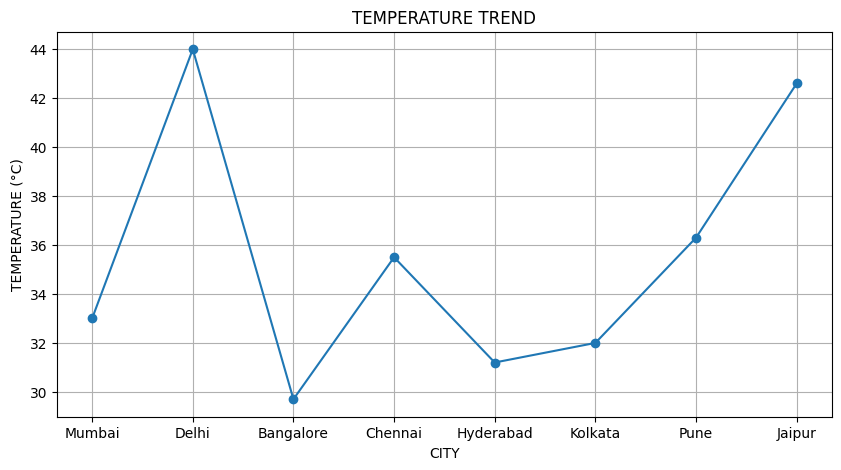

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    weather_df['city'],
    weather_df['temperature'],
    marker='o'
)

plt.title("TEMPERATURE TREND")
plt.xlabel("CITY")
plt.ylabel("TEMPERATURE (°C)")

plt.grid()

plt.show()

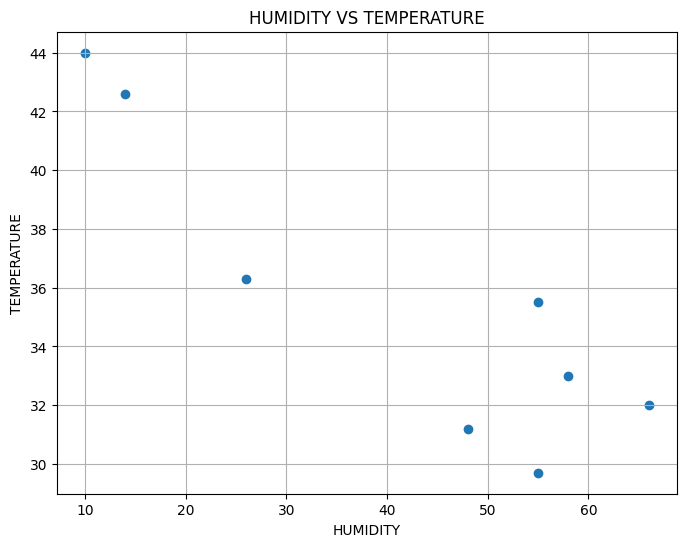

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    weather_df['humidity'],
    weather_df['temperature']
)

plt.title("HUMIDITY VS TEMPERATURE")
plt.xlabel("HUMIDITY")
plt.ylabel("TEMPERATURE")

plt.grid()

plt.show()

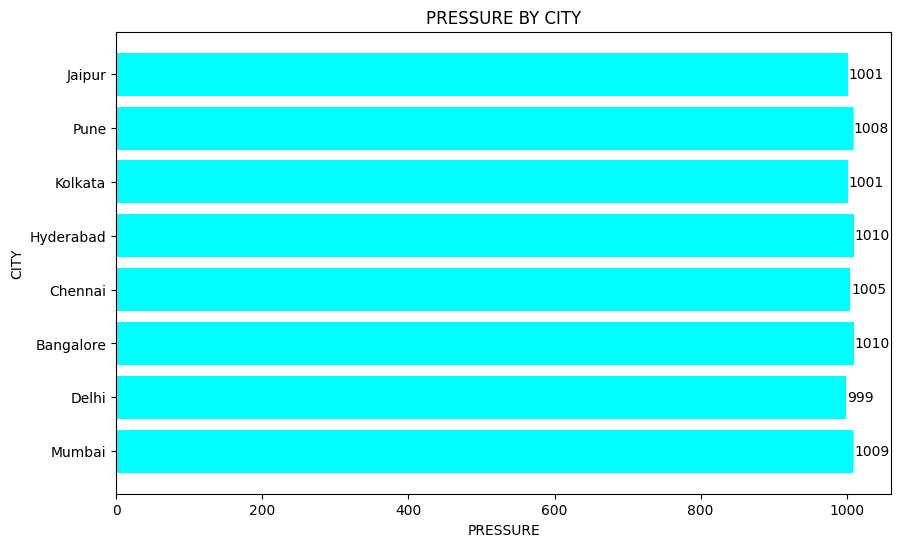

In [43]:
fig, ax = plt.subplots(figsize=(10,6))

bars = plt.barh(
    weather_df['city'],
    weather_df['pressure'],
    color='cyan'
)

plt.title("PRESSURE BY CITY")
plt.xlabel("PRESSURE")
plt.ylabel("CITY")

for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        int(value),
        va='center'
    )

plt.show()

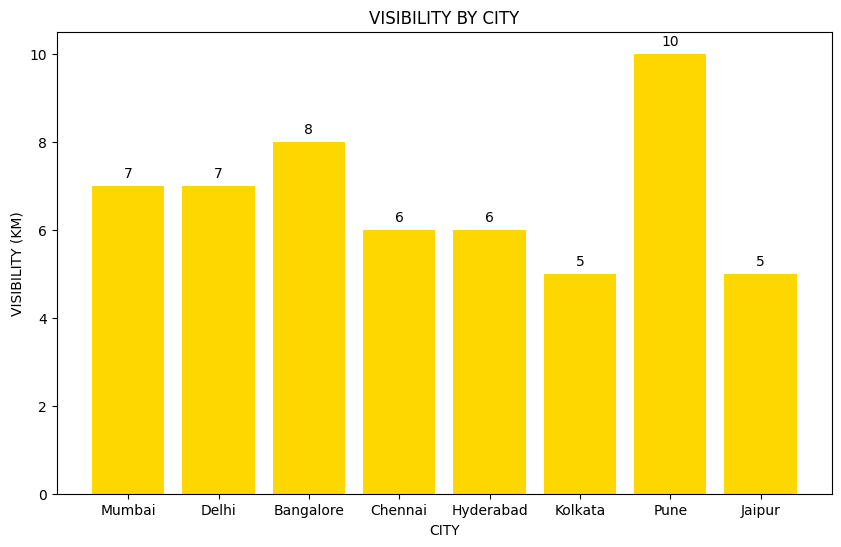

In [44]:
fig, ax = plt.subplots(figsize=(10,6))

bars = plt.bar(
    weather_df['city'],
    weather_df['visibility'],
    color='gold'
)

plt.title("VISIBILITY BY CITY")
plt.xlabel("CITY")
plt.ylabel("VISIBILITY (KM)")

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        value,
        ha='center'
    )

plt.show()

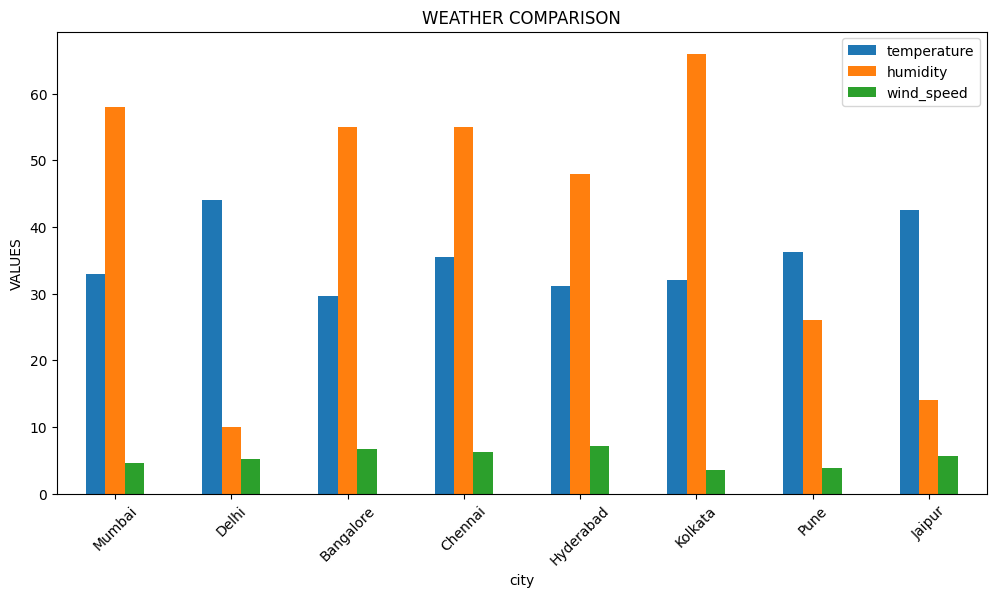

In [45]:
weather_df.plot(
    x='city',
    y=['temperature', 'humidity', 'wind_speed'],
    kind='bar',
    figsize=(12,6)
)

plt.title("WEATHER COMPARISON")

plt.ylabel("VALUES")

plt.xticks(rotation=45)

plt.show()

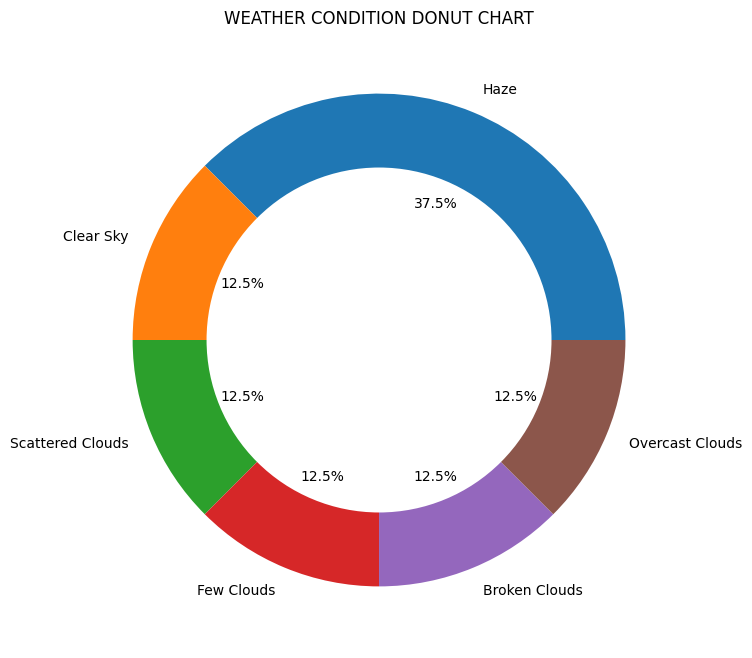

In [46]:
condition_count = weather_df['condition'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    condition_count.values,
    labels=condition_count.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title("WEATHER CONDITION DONUT CHART")

plt.show()

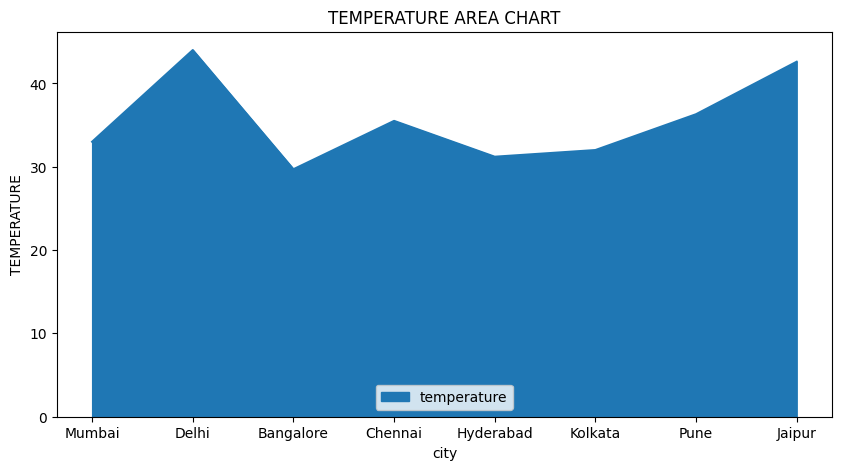

In [47]:
weather_df.plot(
    x='city',
    y='temperature',
    kind='area',
    figsize=(10,5)
)

plt.title("TEMPERATURE AREA CHART")

plt.ylabel("TEMPERATURE")

plt.show()